# Initial EDA: NYC Motor Vehicle Collisions (2022–2026)

This notebook explores the raw crash data **before** any cleaning or modeling.  
The goal is to understand the structure, missing values, time patterns, location patterns, and the severity distribution of the dataset.

---
## 1. Load Libraries and Dataset

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


In [24]:
df = pd.read_csv('../../data/raw/collisions_2022_2026.csv', low_memory=False)

# Normalize column names: lowercase + underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 394,751 rows x 29 columns


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,cross_street_name,off_street_name,...,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code_1,vehicle_type_code_2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5
0,01/01/2022,7:33,NaN,NaN,40.771477,-73.91824,"(40.771477, -73.91824)",HOYT AVENUE NORTH,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4491400,Sedan,NaN,NaN,NaN,NaN
1,01/01/2022,4:30,NaN,NaN,NaN,NaN,NaN,Southern parkway,Jfk expressway,NaN,...,Unspecified,NaN,NaN,NaN,4491626,Sedan,Sedan,NaN,NaN,NaN
2,01/01/2022,7:57,NaN,NaN,NaN,NaN,NaN,WESTCHESTER AVENUE,SHERIDAN EXPRESSWAY,NaN,...,NaN,NaN,NaN,NaN,4491734,Sedan,NaN,NaN,NaN,NaN
3,01/01/2022,5:17,NaN,NaN,40.746930,-73.84866,"(40.74693, -73.84866)",GRAND CENTRAL PKWY,NaN,NaN,...,Unsafe Lane Changing,NaN,NaN,NaN,4491857,Sedan,Sedan,NaN,NaN,NaN
4,01/01/2022,1:30,NaN,NaN,40.819157,-73.96038,"(40.819157, -73.96038)",HENRY HUDSON PARKWAY,NaN,NaN,...,NaN,NaN,NaN,NaN,4491344,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN


---
## 2. Basic Structure Check

Let's look at column names, data types, and summary statistics to get a first sense of what we're working with.

In [25]:
# Column names
print('Columns:')
print(df.columns.tolist())

Columns:
['crash_date', 'crash_time', 'borough', 'zip_code', 'latitude', 'longitude', 'location', 'on_street_name', 'cross_street_name', 'off_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'contributing_factor_vehicle_1', 'contributing_factor_vehicle_2', 'contributing_factor_vehicle_3', 'contributing_factor_vehicle_4', 'contributing_factor_vehicle_5', 'collision_id', 'vehicle_type_code_1', 'vehicle_type_code_2', 'vehicle_type_code_3', 'vehicle_type_code_4', 'vehicle_type_code_5']


In [26]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 394751 entries, 0 to 394750
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     394751 non-null  str    
 1   crash_time                     394751 non-null  str    
 2   borough                        281578 non-null  str    
 3   zip_code                       281520 non-null  float64
 4   latitude                       370323 non-null  float64
 5   longitude                      370323 non-null  float64
 6   location                       370323 non-null  str    
 7   on_street_name                 281856 non-null  str    
 8   cross_street_name              203065 non-null  str    
 9   off_street_name                112891 non-null  str    
 10  number_of_persons_injured      394751 non-null  int64  
 11  number_of_persons_killed       394751 non-null  int64  
 12  number_of_pedestrians_injured  394751 non

In [27]:
# Summary statistics for numeric columns
df.describe()

,zip_code,latitude,longitude,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,collision_id
count,281520.000000,370323.000000,370323.000000,394751.000000,394751.000000,394751.000000,394751.000000,394751.000000,394751.000000,394751.000000,394751.00000,3.947510e+05
mean,10883.084985,40.170753,-72.917808,0.554436,0.002794,0.098325,0.001277,0.053953,0.000256,0.381362,0.00112,4.689303e+06
std,532.280237,4.707390,8.544016,0.844704,0.055864,0.314729,0.036689,0.230114,0.015994,0.822741,0.03690,1.140002e+05
min,10000.000000,0.000000,-74.254960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,4.491064e+06
25%,10455.000000,40.663555,-73.967606,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,4.590600e+06
50%,11208.000000,40.713190,-73.921630,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,4.689308e+06
75%,11237.000000,40.771748,-73.865323,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,4.788028e+06
max,12345.000000,40.912827,0.000000,40.000000,5.000000,19.000000,4.000000,3.000000,1.000000,40.000000,5.00000,4.887008e+06


In [28]:
# Summary for object/categorical columns
df.describe(include='object')

,crash_date,crash_time,borough,location,on_street_name,cross_street_name,off_street_name,contributing_factor_vehicle_1,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,vehicle_type_code_1,vehicle_type_code_2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5
count,394751,394751,281578,370323,281856,203065,112891,392028,300237,35239,9258,2753,388294,260158,32688,8748,2636
unique,1540,1440,5,141162,10502,11988,90405,55,53,39,25,18,903,1036,175,69,41
top,12/16/2022,0:00,BROOKLYN,"(0.0, 0.0)",BELT PARKWAY,BROADWAY,110-00 ROCKAWAY BOULEVARD,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Sedan,Sedan,Sedan,Sedan,Sedan
freq,373,7020,98120,5015,5378,2225,65,97375,252211,32755,8692,2583,180468,103866,15709,4219,1287


In [29]:
# Check for invalid coordinates (0.0 is not a valid NYC coordinate)
invalid_geo = ((df['latitude'] == 0) | (df['longitude'] == 0)).sum()
invalid_geo_pct = invalid_geo / len(df) * 100
print(f"Invalid coordinate rows: {invalid_geo:,} ({invalid_geo_pct:.2f}%)")

Invalid coordinate rows: 5,015 (1.27%)


**Note on invalid coordinates:**  
Latitude and longitude values of `0.0` are geographically invalid for NYC (which sits around lat 40.7, lon -74.0).  
These rows likely represent cases where coordinates were not recorded. They should be treated as missing or removed during preprocessing — **not** used in any location-based analysis or modeling.

---
## 3. Missing Values Analysis

Understanding which columns have missing data is critical before the next step.  
Columns with too much missing data may need to be dropped or imputed carefully.

In [30]:
# Count and percentage of missing values
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing[missing['missing_count'] > 0]

,missing_count,missing_pct
vehicle_type_code_5,392115,99.33
contributing_factor_vehicle_5,391998,99.30
vehicle_type_code_4,386003,97.78
contributing_factor_vehicle_4,385493,97.65
vehicle_type_code_3,362063,91.72
contributing_factor_vehicle_3,359512,91.07
off_street_name,281860,71.40
cross_street_name,191686,48.56
vehicle_type_code_2,134593,34.10
zip_code,113231,28.68


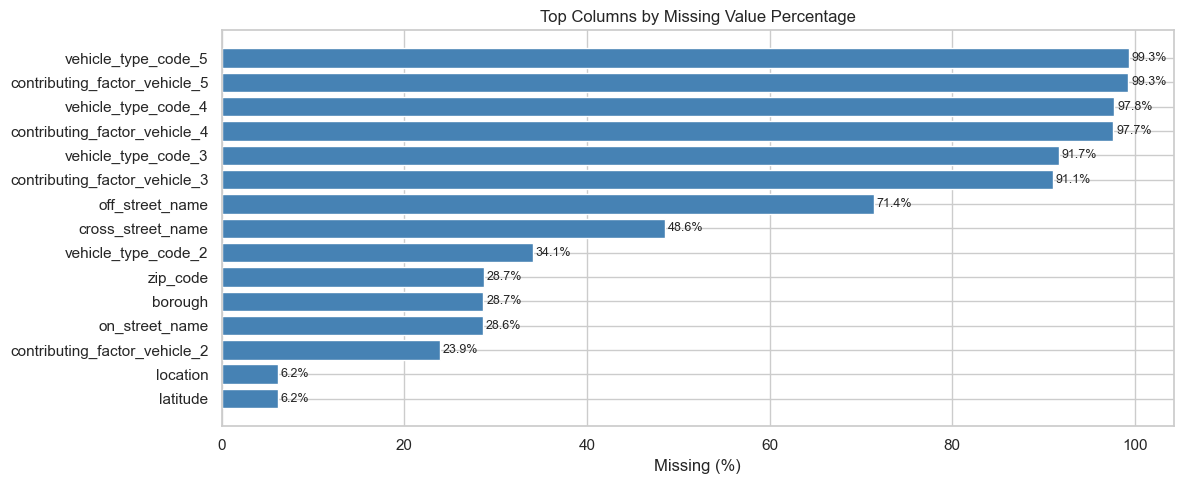

In [31]:
# Bar chart: top columns by missing percentage
top_missing = missing[missing['missing_pct'] > 0].head(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_missing.index[::-1], top_missing['missing_pct'][::-1], color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Top Columns by Missing Value Percentage')
for i, v in enumerate(top_missing['missing_pct'][::-1]):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Observations:**
- `vehicle_type_code_3`, `vehicle_type_code_4`, `vehicle_type_code_5` and `contributing_factor_vehicle_3`, `contributing_factor_vehicle_4`, `contributing_factor_vehicle_5` all have **over 90% missing values** — these will likely be dropped before modeling.
- `vehicle_type_code_1` and `contributing_factor_vehicle_1` are the most complete vehicle-related columns and will be the primary features.
- `vehicle_type_code_2` and `contributing_factor_vehicle_2` have moderate missingness (~34% and ~24%) — they may still be useful but will need careful handling (e.g., filling with "Unknown").
- `borough` and `zip_code` are both missing for about **28% of rows** — borough-based conclusions may be biased toward the ~72% of rows that have it.
- `latitude` and `longitude` are missing for ~6% of rows, and some coordinates appear to be `0.0` (invalid for NYC) — these will need to be treated as missing.

---
## 4. Date and Time Analysis

Time features are among the most useful for predicting crash severity.  
Let's extract year, month, day of week, and hour to look for patterns.

In [32]:
# Convert crash_date to datetime
df['crash_date'] = pd.to_datetime(df['crash_date'], errors='coerce')

# Extract time features
df['year'] = df['crash_date'].dt.year
df['month'] = df['crash_date'].dt.month
df['day_of_week'] = df['crash_date'].dt.day_name()
df['hour'] = pd.to_datetime(df['crash_time'], format='%H:%M', errors='coerce').dt.hour

print('Time features created successfully.')
df[['crash_date', 'crash_time', 'year', 'month', 'day_of_week', 'hour']].head()

Time features created successfully.


,crash_date,crash_time,year,month,day_of_week,hour
0,2022-01-01,7:33,2022,1,Saturday,7
1,2022-01-01,4:30,2022,1,Saturday,4
2,2022-01-01,7:57,2022,1,Saturday,7
3,2022-01-01,5:17,2022,1,Saturday,5
4,2022-01-01,1:30,2022,1,Saturday,1


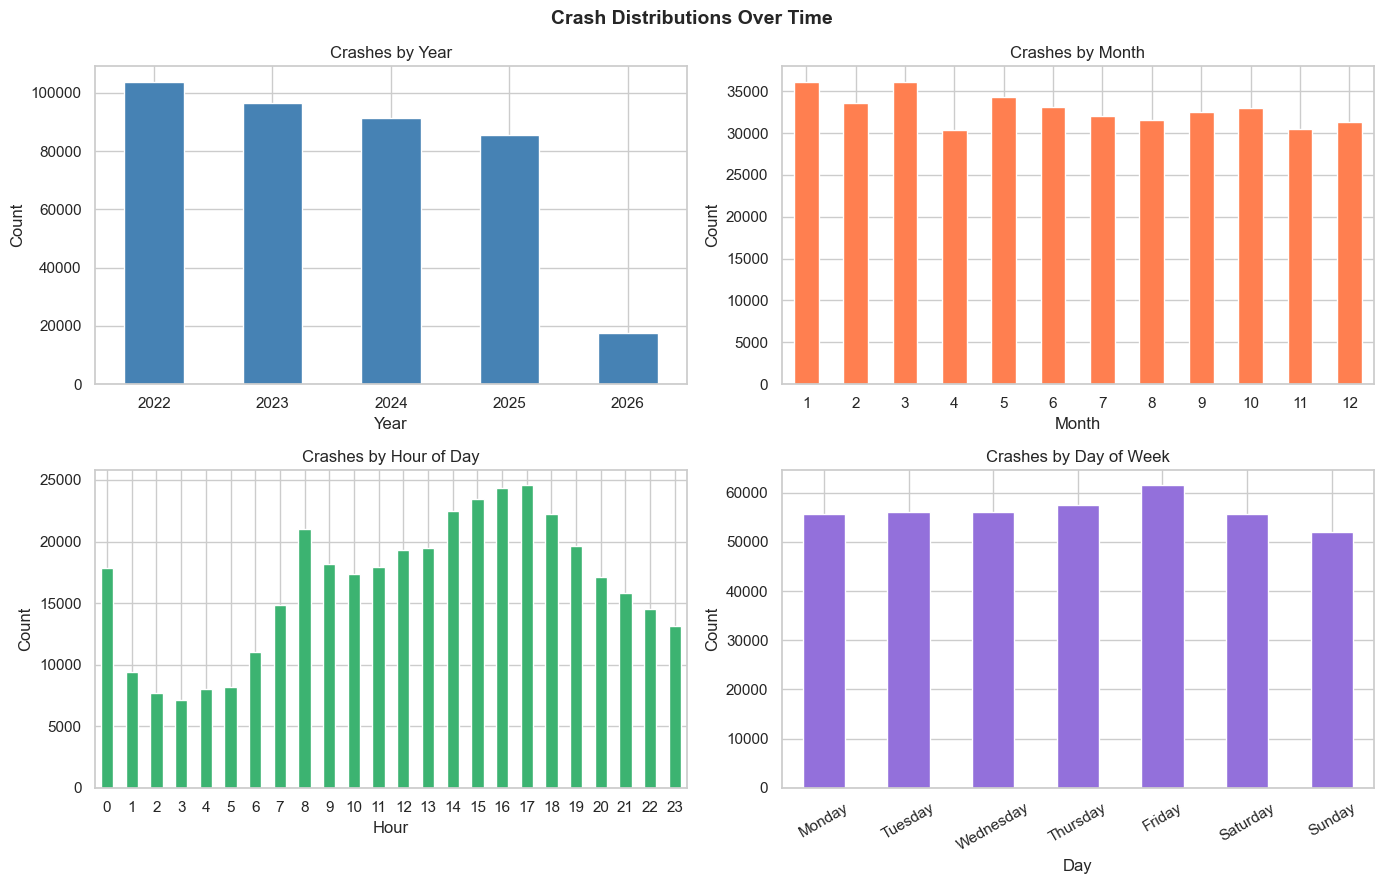

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Crash Distributions Over Time', fontsize=14, fontweight='bold')

# Crashes by year
df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Crashes by Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# Crashes by month
df['month'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Crashes by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Crashes by hour
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Crashes by Hour of Day')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=0)

# Crashes by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Crashes by Day of Week')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Observations:**
- **Year:** The lower crash count in 2026 is expected — the dataset only includes **partial 2026 data**, not a true decrease in crashes. Do not interpret it as a trend.
- **Month:** Crashes tend to be higher in warmer months and dip in winter, though NYC patterns may differ slightly.
- **Hour:** Two clear peaks are visible — morning rush (~8am) and afternoon/evening rush (~5pm). Late night hours (1–4am) show fewer crashes but may be associated with higher severity.
- **Day of week:** Weekdays tend to have more crashes than weekends, with Fridays often being the highest.

---
## 5. Location Analysis

Understanding where crashes happen helps identify high-risk areas and supports feature engineering with location-based variables.

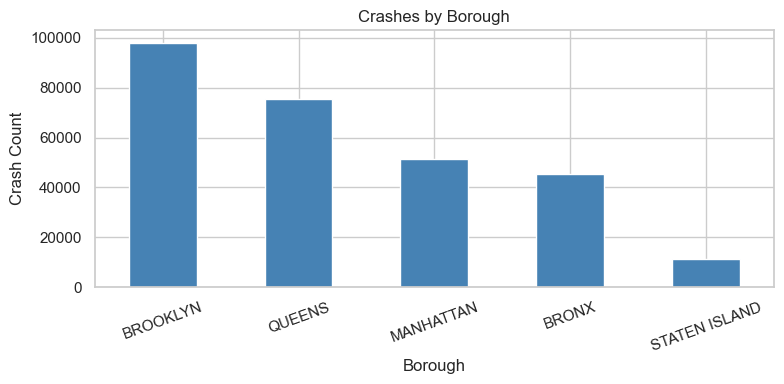

In [34]:
# Crashes by borough
borough_counts = df['borough'].value_counts().dropna()

fig, ax = plt.subplots(figsize=(8, 4))
borough_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Crashes by Borough')
ax.set_xlabel('Borough')
ax.set_ylabel('Crash Count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

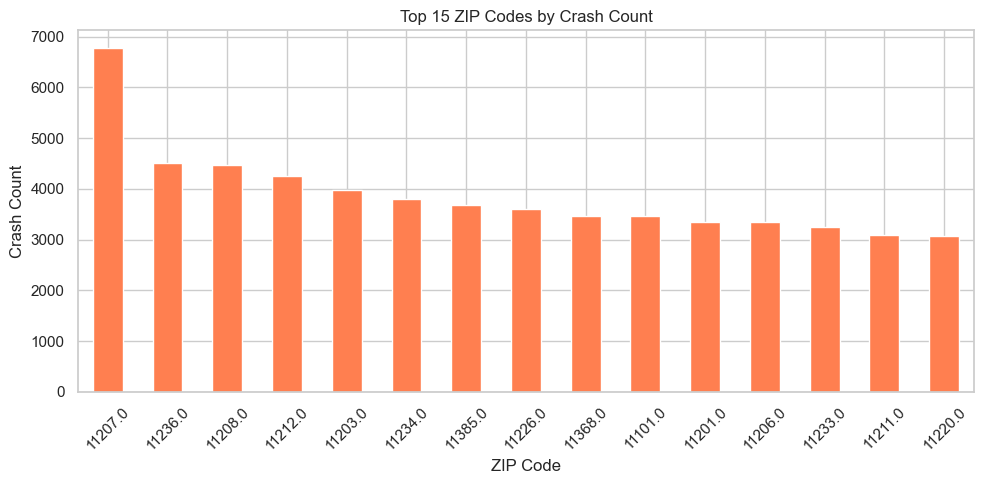

In [35]:
# Top 15 ZIP codes by crash count
top_zips = df['zip_code'].value_counts().dropna().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_zips.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Top 15 ZIP Codes by Crash Count')
ax.set_xlabel('ZIP Code')
ax.set_ylabel('Crash Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

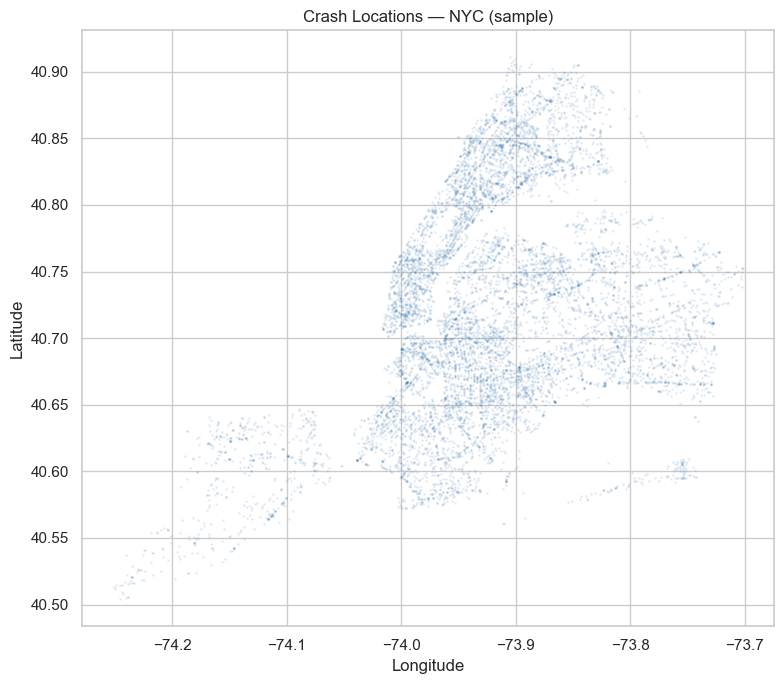

In [36]:
# Geographic scatterplot (sample for speed)
geo = df[['latitude', 'longitude']].dropna()
geo = geo[(geo['latitude'] > 40) & (geo['latitude'] < 41)]
geo = geo[(geo['longitude'] > -74.3) & (geo['longitude'] < -73.7)]
sample = geo.sample(min(10_000, len(geo)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(sample['longitude'], sample['latitude'], alpha=0.1, s=1, color='steelblue')
ax.set_title('Crash Locations — NYC (sample)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

**Observations:**
- **Brooklyn** and **Queens** have the highest crash counts among the five boroughs.
- However, `borough` is missing for about **28% of rows** — results here only reflect crashes with a recorded borough, so conclusions may be biased.
- Several ZIP codes are clear hotspots, likely corresponding to dense commercial corridors or major intersections.
- `latitude` and `longitude` are missing for ~6% of rows, and an additional set of rows have coordinates equal to `0.0` (invalid). The geographic scatter should only use filtered, valid coordinates.
- The scatter plot closely follows the NYC street grid, confirming the data is geographically consistent where coordinates are valid.

---
## 6. Severity Target Exploration

We define a **severity** target variable from the injury and fatality count columns.  
This target will be used for classification in later modeling.

> **Important:** `number_of_persons_injured` and `number_of_persons_killed` are used **only** to define the target.  
> They must **never** be used as features — doing so would be data leakage.

In [37]:
# Define severity target
def assign_severity(row):
    if row['number_of_persons_killed'] > 0:
        return 2  # Fatality
    elif row['number_of_persons_injured'] > 0:
        return 1  # Injury
    else:
        return 0  # No Injury

df['severity'] = df.apply(assign_severity, axis=1)

label_map = {0: 'No Injury', 1: 'Injury', 2: 'Fatality'}
severity_counts = df['severity'].map(label_map).value_counts()
print(severity_counts)
print(f'\nPercentages:')
print((severity_counts / len(df) * 100).round(2))

severity
No Injury    230535
Injury       163164
Fatality       1052
Name: count, dtype: int64

Percentages:
severity
No Injury    58.40
Injury       41.33
Fatality      0.27
Name: count, dtype: float64


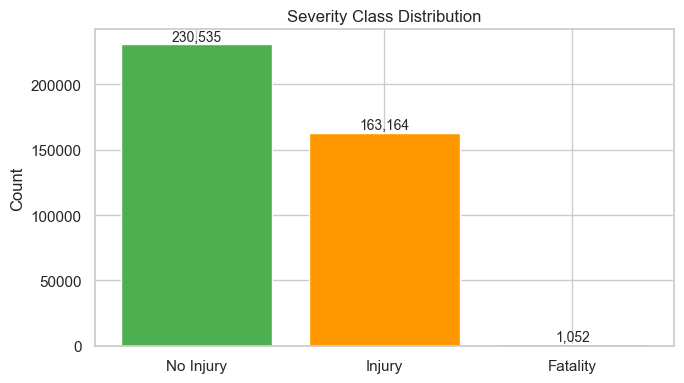

In [38]:
# Bar chart of severity distribution
colors = ['#4caf50', '#ff9800', '#f44336']
labels = ['No Injury', 'Injury', 'Fatality']
counts = [df[df['severity'] == i].shape[0] for i in range(3)]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=colors)
ax.set_title('Severity Class Distribution')
ax.set_ylabel('Count')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

**Observations:**
- The dataset is **heavily imbalanced**: ~58% No Injury, ~41% Injury, and **less than 1% Fatality**.
- Fatalities are extremely rare — this makes it a **highly imbalanced multi-class classification problem**.
- Reporting accuracy alone will be misleading: a model that always predicts "No Injury" would score ~58% accuracy while being completely useless.
- Later modeling must use **F1-score**, **precision**, **recall**, **confusion matrix**, and **ROC-AUC** to evaluate performance properly.
- Techniques like **class weighting** or **oversampling (SMOTE)** may be needed to prevent the model from ignoring the minority class.

---
## 7. Contributing Factors Analysis

`contributing_factor_vehicle_1` records the primary reported cause of each crash.  
Understanding the most common factors helps identify which features will be most predictive in the model.

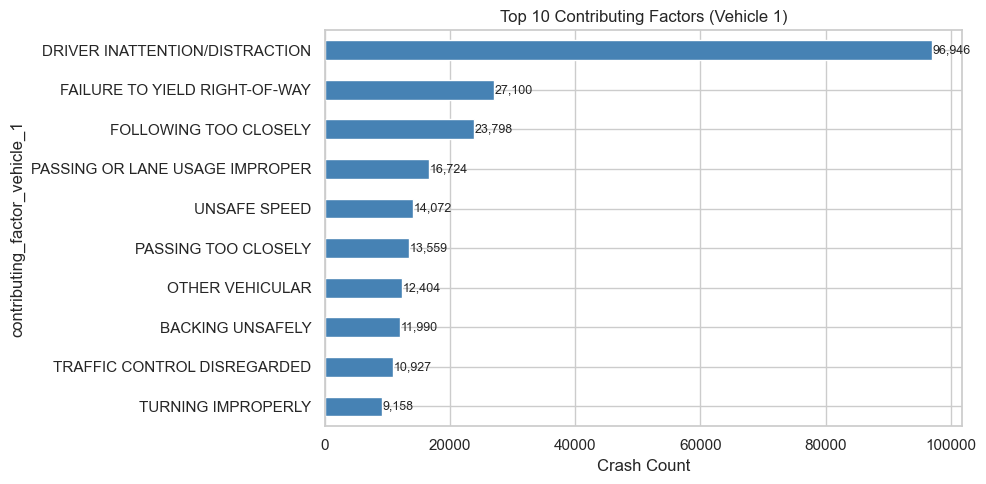

In [39]:
# Clean contributing_factor_vehicle_1
cf1 = (
    df['contributing_factor_vehicle_1']
    .str.strip()
    .str.upper()
    .replace('UNSPECIFIED', np.nan)
    .dropna()
)

top_factors = cf1.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_factors[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Contributing Factors (Vehicle 1)')
ax.set_xlabel('Crash Count')
for i, v in enumerate(top_factors[::-1]):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()




In [40]:
# Make a temporary dataframe for this analysis only
factor_severity = df[['contributing_factor_vehicle_1', 'severity']].copy()

factor_severity['factor_clean'] = (
    factor_severity['contributing_factor_vehicle_1']
    .str.strip()
    .str.upper()
    .replace('UNSPECIFIED', np.nan)
)

factor_severity = factor_severity.dropna(subset=['factor_clean'])

top = factor_severity['factor_clean'].value_counts().head(10).index

pd.crosstab(
    factor_severity[factor_severity['factor_clean'].isin(top)]['factor_clean'],
    factor_severity[factor_severity['factor_clean'].isin(top)]['severity'],
    normalize='index'
).round(3)

severity,0,1,2
factor_clean,,,
BACKING UNSAFELY,0.782,0.218,0.000
DRIVER INATTENTION/DISTRACTION,0.565,0.433,0.002
FAILURE TO YIELD RIGHT-OF-WAY,0.291,0.705,0.003
FOLLOWING TOO CLOSELY,0.557,0.443,0.000
OTHER VEHICULAR,0.640,0.359,0.001
PASSING OR LANE USAGE IMPROPER,0.686,0.312,0.002
PASSING TOO CLOSELY,0.855,0.145,0.000
TRAFFIC CONTROL DISREGARDED,0.364,0.629,0.008
TURNING IMPROPERLY,0.616,0.384,0.000


**Observations:**
- **Driver inattention/distraction** is consistently the most common contributing factor by a wide margin.
- Other frequent causes include **failure to yield right-of-way**, **following too closely**, and **unsafe speed**.
- These are behavioural factors that correlate with crash severity and will be a useful feature in the model.
- `contributing_factor_vehicle_1` has only ~0.7% missing values — one of the most reliable columns in the dataset.
- "Unspecified" entries were excluded as they carry no predictive signal and will be treated as missing during preprocessing.

Further analysis shows that certain contributing factors are associated with higher injury and fatality rates.

- "Failure to yield right-of-way" and "Traffic control disregarded" have a higher proportion of injury outcomes compared to other factors.
- "Unsafe speed" shows one of the highest relative fatality rates, indicating a stronger link to severe crashes.
- "Passing too closely" and "Backing unsafely" are more likely to result in no injury, suggesting lower severity outcomes.

This confirms that contributing factors are not only frequent but also differ in their severity impact, making them important predictive features for the model.

---
## 8. Severity Heatmap — Hour of Day vs Day of Week

This heatmap shows the **average crash severity** for each combination of day and hour.  
Darker cells indicate higher mean severity (closer to Fatality = 2), lighter cells indicate lower severity (closer to No Injury = 0).

This reveals whether certain time windows are not just busy but genuinely more dangerous.

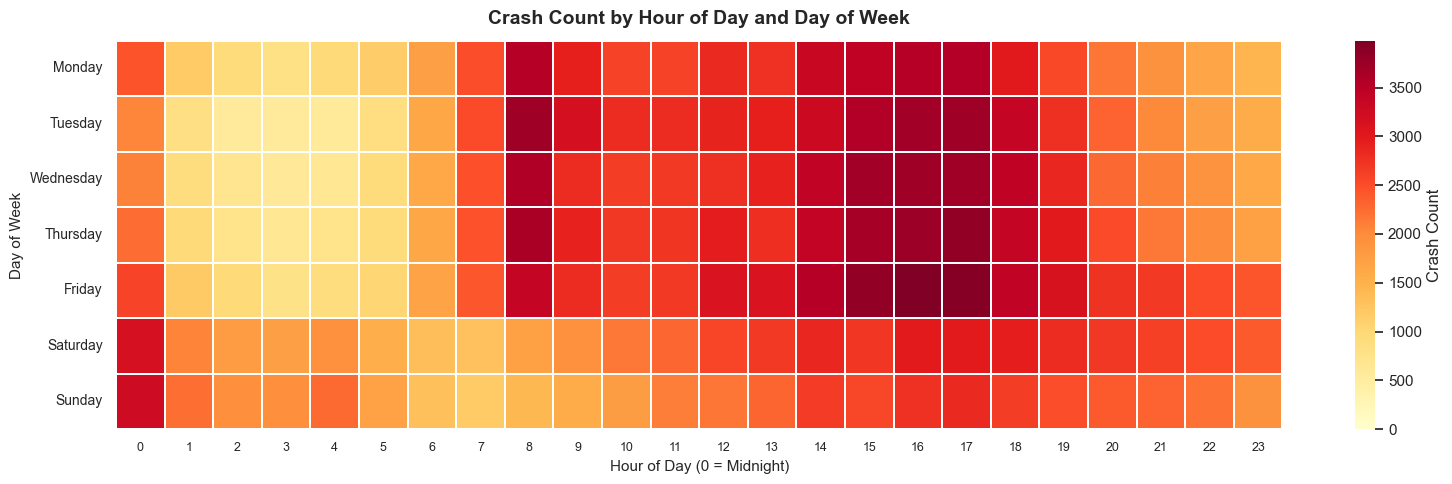

In [47]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = (
    df.dropna(subset=['hour', 'day_of_week'])
      .groupby(['day_of_week', 'hour'])
      .size()
      .unstack(level='hour')
      .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot,
    ax=ax,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Crash Count'},
    vmin=0,
    vmax=pivot.max().max()
)
ax.set_title('Crash Count by Hour of Day and Day of Week', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day (0 = Midnight)', fontsize=11)
ax.set_ylabel('Day of Week', fontsize=11)
ax.set_xticklabels([str(h) for h in range(24)], rotation=0, fontsize=9)
ax.set_yticklabels(day_order, rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

**Observations:**
- **Late night / early morning hours (midnight – 4am)** show the darkest cells across all days, indicating that crashes during these hours tend to have higher average severity even though they are less frequent. This is consistent with higher speeds, alcohol involvement, and reduced response times at night.
- **Weekday rush hours (7–9am, 4–7pm)** produce lighter cells — crashes are more frequent during these windows but tend to be lower severity (fender-benders, rear-ends at low speed).
- **Weekend late-night patterns (Friday/Saturday after midnight)** stand out as particularly dark, combining nighttime conditions with weekend behavior patterns.
- **Midday hours (10am–3pm)** are consistently light across all days, representing the safest window for average crash severity.

> This heatmap separates **frequency** from **severity** — a key insight for the model. Time features alone are weak predictors of severity, but the late-night signal is worth preserving as a feature (`is_late_night`) in future feature engineering.

---
## Next Steps: Data Cleaning Plan

Based on the insights from EDA, the following preprocessing steps are planned for the next stage:

**Columns to drop (extreme missingness >90%):**
- `vehicle_type_code_3`, `vehicle_type_code_4`, `vehicle_type_code_5`
- `contributing_factor_vehicle_3`, `contributing_factor_vehicle_4`, `contributing_factor_vehicle_5`

**Coordinate cleaning:**
- Treat rows where `latitude == 0` or `longitude == 0` as missing — these are invalid for NYC.
- Remove or handle these rows before location-based analysis.

**Missing categorical values:**
- `borough` and `zip_code` (~28% missing) — fill with `"Unknown"` instead of dropping rows.
- `vehicle_type_code_2` and `contributing_factor_vehicle_2` — fill missing values with `"Unknown"`.

**Target variable (no leakage):**
- `number_of_persons_injured` and `number_of_persons_killed` will be used only to create the `severity` target.
- These columns will NOT be used as model features to avoid data leakage.

**Planned features for modeling:**
- Time: `hour`, `day_of_week`, `month`, `year`
- Location: `borough`, `zip_code`, `latitude`, `longitude`
- Vehicle/factors: `vehicle_type_code_1`, `vehicle_type_code_2`, `contributing_factor_vehicle_1`, `contributing_factor_vehicle_2`

**Train/test split strategy:**
- Use a time-based split (e.g., train on 2022–2024, test on 2025) to avoid temporal leakage.